# 10 — True Normal-vs-Abnormal Mammogram Anomaly Detection (mini-MIAS)

This notebook implements a **true normal-vs-abnormal anomaly-detection experiment** using the **mini-MIAS** mammography dataset.

### Research question
Can a one-class model fitted **only on genuinely normal mammograms** distinguish normal mammograms from mammograms containing an abnormality?

### mini-MIAS label mapping
- `NORM` → `0 = normal`
- `CALC`, `CIRC`, `SPIC`, `MISC`, `ARCH`, `ASYM` → `1 = abnormal`

### Scientific guardrails
- Benign abnormalities are still **abnormal**, not normal.
- The 322 mammograms are grouped as 161 left/right patient pairs before splitting.
- Patient-level train/validation/test separation is enforced.
- The one-class detector is fitted using **normal training images only**.
- Thresholds are selected on validation data and then frozen for the locked test set.
- The primary feature extractor is an **ImageNet-pretrained ResNet-50**, frozen before feature extraction.
- Normal and abnormal images come from the same mini-MIAS source, avoiding the most obvious cross-dataset source-label confounding.

This experiment is reported separately from the CBIS-DDSM benign-vs-malignant experiments because it answers a different question.


## 1. Setup and Project Paths

The notebook expects the project root:

`/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification`

The downloaded mini-MIAS files should be under:

```text
Data/Normal_Abnormal/
├── Info.txt
├── all-mias/
│   ├── Info.txt
│   ├── mdb001.pgm
│   ├── ...
│   └── mdb322.pgm
└── ...
```

The notebook automatically parses mini-MIAS `Info.txt` and creates:

`Data/Normal_Abnormal/normal_abnormal_manifest.csv`

No manual movement of the 322 mammograms into separate class folders is required.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import random
import re
import platform
import hashlib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import ndimage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

try:
    RESAMPLE_BILINEAR = Image.Resampling.BILINEAR
except AttributeError:
    RESAMPLE_BILINEAR = Image.BILINEAR


# ============================================================
# Project paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "Data",
    "Normal_Abnormal",
)

MANIFEST_PATH = os.path.join(
    DATASET_DIR,
    "normal_abnormal_manifest.csv",
)

MIAS_DIR = os.path.join(
    DATASET_DIR,
    "all-mias",
)

MIAS_INFO_CANDIDATES = [
    os.path.join(MIAS_DIR, "Info.txt"),
    os.path.join(DATASET_DIR, "Info.txt"),
]

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Results",
    "10_Normal_vs_Abnormal_Anomaly_Detection",
)

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "Figures",
    "Anomaly",
)

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# Experiment configuration
# ============================================================

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 16
NUM_WORKERS = 0

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

BOOTSTRAP_N = 1000
MAX_PCA_COMPONENTS = 128
PCA_VARIANCE_TARGET = 0.95

# This should remain False for the final dissertation experiment.
# Setting it True would permit a source-confounded exploratory run.
ALLOW_SOURCE_CONFOUNDED_EXPLORATORY = False

# Folder auto-builder source name. Change this to the real dataset name
# if you use the normal/<patient>/ and abnormal/<patient>/ folder layout.
AUTO_FOLDER_SOURCE_NAME = "mini-MIAS"

PREPROCESS_VERSION = "breastcrop_v1_true_normal_abnormal"

CACHE_DIR = (
    f"/content/normal_abnormal_cache_"
    f"{PREPROCESS_VERSION}_{IMG_SIZE}"
)

FEATURE_CACHE = os.path.join(
    OUTPUT_DIR,
    "features_imagenet_resnet50_breastcrop512.npz",
)


# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PIN_MEMORY = bool(torch.cuda.is_available())


# ============================================================
# Environment
# ============================================================

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Manifest:", MANIFEST_PATH)
print("Output directory:", OUTPUT_DIR)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)

if not os.path.isdir(PROJECT_DIR):
    raise FileNotFoundError(
        f"Project directory not found:\n{PROJECT_DIR}"
    )


Mounted at /content/drive
Project directory: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification
Dataset directory: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Data/Normal_Abnormal
Manifest: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Data/Normal_Abnormal/normal_abnormal_manifest.csv
Output directory: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/10_Normal_vs_Abnormal_Anomaly_Detection
Device: cuda
GPU: Tesla T4
Python: 3.12.13
PyTorch: 2.11.0+cu128


## 2. Build the mini-MIAS Normal/Abnormal Manifest

The notebook reads the mini-MIAS truth data and creates exactly one row per mammogram.

Important details:
- `NORM` is treated as normal.
- Every other listed abnormality category is treated as abnormal, regardless of whether its severity is benign or malignant.
- Some mammograms have more than one abnormality annotation; these are collapsed to **one image-level row**.
- Patient IDs are created from the left/right image pairs so both breasts from the same patient always remain in the same split.


In [4]:
IMAGE_EXTENSIONS = {".pgm", ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

ABNORMAL_CLASSES = {
    "CALC",
    "CIRC",
    "SPIC",
    "MISC",
    "ARCH",
    "ASYM",
}

ALL_MIAS_CLASSES = ABNORMAL_CLASSES | {"NORM"}


def stable_sample_id(path):
    return hashlib.sha1(
        str(path).encode("utf-8")
    ).hexdigest()[:20]


def resolve_image_path(path_value):
    path_value = str(path_value).strip()

    if os.path.isabs(path_value) and os.path.isfile(path_value):
        return os.path.abspath(path_value)

    candidates = [
        os.path.join(PROJECT_DIR, path_value),
        os.path.join(DATASET_DIR, path_value),
        os.path.join(MIAS_DIR, path_value),
    ]

    for candidate in candidates:
        if os.path.isfile(candidate):
            return os.path.abspath(candidate)

    return None


def find_mias_info_file():
    for candidate in MIAS_INFO_CANDIDATES:
        if os.path.isfile(candidate):
            return candidate

    raise FileNotFoundError(
        "mini-MIAS Info.txt was not found. Checked:\n"
        + "\n".join(MIAS_INFO_CANDIDATES)
    )


def build_mias_manifest():
    if not os.path.isdir(MIAS_DIR):
        raise FileNotFoundError(
            f"mini-MIAS image directory not found:\n{MIAS_DIR}"
        )

    info_path = find_mias_info_file()

    # Parse only true data lines.
    # Example:
    # mdb001 G CIRC B 535 425 197
    # mdb003 D NORM
    pattern = re.compile(
        r"^(mdb\d{3})\s+"
        r"([FGD])\s+"
        r"(CALC|CIRC|SPIC|MISC|ARCH|ASYM|NORM)"
        r"(?:\s+([BM]))?"
    )

    annotations = {}

    with open(
        info_path,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as f:
        for raw_line in f:
            line = raw_line.strip()
            match = pattern.match(line)

            if not match:
                continue

            ref, tissue, abnormality, severity = match.groups()

            entry = annotations.setdefault(
                ref,
                {
                    "tissue": tissue,
                    "abnormalities": set(),
                    "severities": set(),
                },
            )

            entry["abnormalities"].add(abnormality)

            if severity:
                entry["severities"].add(severity)

    rows = []

    image_files = sorted(
        p for p in Path(MIAS_DIR).glob("mdb*.pgm")
        if p.is_file()
    )

    if len(image_files) != 322:
        raise ValueError(
            f"Expected 322 mini-MIAS PGM files but found {len(image_files)} "
            f"in {MIAS_DIR}"
        )

    for image_path in image_files:
        ref = image_path.stem

        if ref not in annotations:
            raise ValueError(
                f"No truth-data entry found for {ref} in {info_path}"
            )

        image_number = int(ref.replace("mdb", ""))

        # mini-MIAS uses consecutive right/left mammograms for each patient:
        # 001/002 -> patient 001, 003/004 -> patient 002, ...
        patient_number = (image_number + 1) // 2
        patient_id = f"mias_patient_{patient_number:03d}"

        side = "right" if image_number % 2 == 1 else "left"

        abnormality_set = annotations[ref]["abnormalities"]

        if "NORM" in abnormality_set and len(abnormality_set) > 1:
            raise ValueError(
                f"{ref} is annotated as NORM and abnormal simultaneously: "
                f"{sorted(abnormality_set)}"
            )

        label = 0 if abnormality_set == {"NORM"} else 1

        severity_set = annotations[ref]["severities"]

        rows.append({
            "image_path": str(image_path),
            "patient_id": patient_id,
            "label": int(label),
            "source": "mini-MIAS",
            "sample_id": ref,
            "side": side,
            "tissue": annotations[ref]["tissue"],
            "abnormality": "|".join(sorted(abnormality_set)),
            "pathology": (
                "|".join(sorted(severity_set))
                if severity_set
                else "normal"
            ),
        })

    manifest = pd.DataFrame(rows)

    if len(manifest) != 322:
        raise AssertionError("Manifest should contain exactly 322 image rows.")

    if manifest["patient_id"].nunique() != 161:
        raise AssertionError(
            "Expected exactly 161 patient groups from the 322 paired mammograms."
        )

    if not manifest["sample_id"].is_unique:
        raise AssertionError("sample_id must be unique after annotation collapsing.")

    manifest.to_csv(
        MANIFEST_PATH,
        index=False,
    )

    print("mini-MIAS manifest created:")
    print(MANIFEST_PATH)
    print("Rows:", len(manifest))
    print("Patients:", manifest["patient_id"].nunique())

    return manifest


# Rebuild deterministically from the downloaded mini-MIAS source.
manifest = build_mias_manifest()

print("\nImage-level class counts:")
display(
    manifest["label"]
    .value_counts()
    .rename(index={0: "normal", 1: "abnormal"})
    .rename("images")
    .to_frame()
)

print("\nAbnormality labels:")
display(
    manifest["abnormality"]
    .value_counts()
    .rename("images")
    .to_frame()
)

display(manifest.head(10))


mini-MIAS manifest created:
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Data/Normal_Abnormal/normal_abnormal_manifest.csv
Rows: 322
Patients: 161

Image-level class counts:


,images
label,
normal,207
abnormal,115



Abnormality labels:


,images
abnormality,
NORM,207
CALC,25
CIRC,23
SPIC,19
ARCH,19
ASYM,15
MISC,14


,image_path,patient_id,label,source,sample_id,side,tissue,abnormality,pathology
0,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_001,1,mini-MIAS,mdb001,right,G,CIRC,B
1,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_001,1,mini-MIAS,mdb002,left,G,CIRC,B
2,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_002,0,mini-MIAS,mdb003,right,D,NORM,normal
3,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_002,0,mini-MIAS,mdb004,left,D,NORM,normal
4,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_003,1,mini-MIAS,mdb005,right,F,CIRC,B
5,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_003,0,mini-MIAS,mdb006,left,F,NORM,normal
6,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_004,0,mini-MIAS,mdb007,right,G,NORM,normal
7,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_004,0,mini-MIAS,mdb008,left,G,NORM,normal
8,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_005,0,mini-MIAS,mdb009,right,F,NORM,normal
9,/content/drive/MyDrive/deep_learning_tumor_det...,mias_patient_005,1,mini-MIAS,mdb010,left,F,CIRC,B


## 3. Validate Labels, Paths, Patients and Dataset Source

This cell validates the generated mini-MIAS manifest, image paths, unique sample IDs, class composition and patient grouping.

Because both normal and abnormal mammograms come from mini-MIAS, the experiment does not have the simple cross-dataset problem where source identity perfectly predicts the class.


In [5]:
required_columns = {
    "image_path",
    "patient_id",
    "label",
    "source",
}

missing = required_columns - set(manifest.columns)

if missing:
    raise KeyError(
        "Manifest is missing required columns: "
        + ", ".join(sorted(missing))
    )

df = manifest.copy()

# ------------------------------------------------------------
# Normalize labels
# ------------------------------------------------------------

label_map = {
    "0": 0,
    "normal": 0,
    "negative": 0,
    "1": 1,
    "abnormal": 1,
    "positive": 1,
}

def normalize_label(value):
    if isinstance(value, (int, np.integer)):
        if int(value) in (0, 1):
            return int(value)

    if isinstance(value, float) and not np.isnan(value):
        if int(value) in (0, 1) and float(value).is_integer():
            return int(value)

    key = str(value).strip().lower()

    if key in label_map:
        return label_map[key]

    raise ValueError(
        f"Unsupported label value: {value!r}. "
        "Use 0/normal or 1/abnormal."
    )

df["label"] = df["label"].map(normalize_label)

df["patient_id"] = (
    df["patient_id"]
    .astype(str)
    .str.strip()
)

df["source"] = (
    df["source"]
    .astype(str)
    .str.strip()
)

if (df["patient_id"] == "").any():
    raise ValueError("Blank patient_id values found.")

if (df["source"] == "").any():
    raise ValueError("Blank source values found.")


# ------------------------------------------------------------
# Resolve image paths
# ------------------------------------------------------------

df["full_image_path"] = (
    df["image_path"]
    .apply(resolve_image_path)
)

missing_paths = df[df["full_image_path"].isna()].copy()

if len(missing_paths):
    print(
        missing_paths[
            ["image_path", "patient_id", "label", "source"]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_paths)} manifest images could not be located. "
        "Fix image_path values before continuing."
    )


# ------------------------------------------------------------
# Stable sample IDs
# ------------------------------------------------------------

if "sample_id" not in df.columns:
    df["sample_id"] = ""

df["sample_id"] = df["sample_id"].fillna("").astype(str).str.strip()

blank_sid = df["sample_id"] == ""

df.loc[blank_sid, "sample_id"] = (
    df.loc[blank_sid, "full_image_path"]
    .apply(stable_sample_id)
)

if not df["sample_id"].is_unique:
    dup = df[df["sample_id"].duplicated(keep=False)].sort_values("sample_id")
    display(dup.head(20))
    raise ValueError("Duplicate sample_id values found.")


# ------------------------------------------------------------
# Basic class checks
# ------------------------------------------------------------

if set(df["label"].unique()) != {0, 1}:
    raise ValueError(
        "The dataset must contain BOTH genuine normal (0) "
        "and abnormal (1) mammograms."
    )

print("\nClass counts:")
display(
    df.groupby("label")
      .agg(images=("sample_id", "count"),
           patients=("patient_id", "nunique"))
      .rename(index={0: "normal", 1: "abnormal"})
)


# ------------------------------------------------------------
# Source-label confounding check
# ------------------------------------------------------------

source_table = pd.crosstab(
    df["source"],
    df["label"],
).rename(columns={0: "normal", 1: "abnormal"})

for col in ["normal", "abnormal"]:
    if col not in source_table.columns:
        source_table[col] = 0

source_table = source_table[["normal", "abnormal"]]

print("\nSource x label table:")
display(source_table)

source_has_one_label_only = (
    (source_table > 0).sum(axis=1) == 1
)

perfect_source_confounding = (
    len(source_table) > 1
    and source_has_one_label_only.all()
)

if perfect_source_confounding:
    message = (
        "SOURCE-LABEL CONFOUNDING DETECTED.\n"
        "Every source contains only one class. A model could distinguish "
        "dataset/scanner/preprocessing differences instead of pathology.\n\n"
        "For the final dissertation experiment, use a dataset/source that "
        "contains BOTH normal and abnormal mammograms."
    )

    if ALLOW_SOURCE_CONFOUNDED_EXPLORATORY:
        print("WARNING:", message)
        print("Proceeding only because ALLOW_SOURCE_CONFOUNDED_EXPLORATORY=True.")
    else:
        raise RuntimeError(message)

print("\nDataset validation passed.")



Class counts:


,images,patients
label,,
normal,207,154
abnormal,115,108



Source x label table:


label,normal,abnormal
source,,
mini-MIAS,207,115



Dataset validation passed.


## 4. Patient-Level Train / Validation / Locked-Test Split

A deterministic 70/15/15 split is generated at **patient level**.

mini-MIAS contains paired left/right mammograms. Both mammograms from the same patient are therefore assigned to the same split.

Patient-level stratification uses whether a patient has at least one abnormal mammogram. The locked test set is not used for threshold selection.


In [6]:
def normalize_split(value):
    value = str(value).strip().lower()

    mapping = {
        "train": "train",
        "training": "train",
        "val": "validation",
        "valid": "validation",
        "validation": "validation",
        "test": "locked_test",
        "locked_test": "locked_test",
        "locked test": "locked_test",
    }

    return mapping.get(value, value)


use_existing_split = False  # Always regenerate mini-MIAS split deterministically.

if use_existing_split:
    df["split"] = df["split"].map(normalize_split)

    allowed_splits = {
        "train",
        "validation",
        "locked_test",
    }

    unexpected = set(df["split"].dropna().unique()) - allowed_splits

    if unexpected:
        raise ValueError(
            f"Unexpected split labels: {sorted(unexpected)}"
        )

    if df["split"].isna().any():
        raise ValueError(
            "Some manifest rows have split values while others are blank. "
            "Either provide all split assignments or remove the split column."
        )

    print("Using split assignments supplied in the manifest.")

else:
    patient_table = (
        df.groupby("patient_id", as_index=False)
          .agg(
              patient_label=("label", "max"),
              images=("sample_id", "count"),
          )
    )

    class_patient_counts = (
        patient_table["patient_label"]
        .value_counts()
        .sort_index()
    )

    print("Patient-level class counts before splitting:")
    print(class_patient_counts)

    if class_patient_counts.min() < 7:
        raise ValueError(
            "Too few patients in at least one class for a stable 70/15/15 "
            "patient-level split. Add more data or provide justified "
            "predefined split assignments."
        )

    train_pat, temp_pat = train_test_split(
        patient_table,
        test_size=(1.0 - TRAIN_FRACTION),
        stratify=patient_table["patient_label"],
        random_state=SEED,
    )

    test_share_of_temp = TEST_FRACTION / (VAL_FRACTION + TEST_FRACTION)

    val_pat, test_pat = train_test_split(
        temp_pat,
        test_size=test_share_of_temp,
        stratify=temp_pat["patient_label"],
        random_state=SEED,
    )

    split_map = {}

    split_map.update({
        pid: "train"
        for pid in train_pat["patient_id"]
    })

    split_map.update({
        pid: "validation"
        for pid in val_pat["patient_id"]
    })

    split_map.update({
        pid: "locked_test"
        for pid in test_pat["patient_id"]
    })

    df["split"] = df["patient_id"].map(split_map)

    print("Generated deterministic patient-level split.")


train_df = (
    df[df["split"] == "train"]
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "validation"]
    .reset_index(drop=True)
)

test_df = (
    df[df["split"] == "locked_test"]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------

for a, b, name in [
    (train_df, val_df, "train vs validation"),
    (train_df, test_df, "train vs locked_test"),
    (val_df, test_df, "validation vs locked_test"),
]:
    overlap = set(a["patient_id"]) & set(b["patient_id"])

    if overlap:
        raise RuntimeError(
            f"Patient leakage detected in {name}: "
            f"{len(overlap)} overlapping patients."
        )


# ------------------------------------------------------------
# Required class composition
# ------------------------------------------------------------

if (train_df["label"] == 0).sum() < 20:
    raise ValueError(
        "Fewer than 20 normal training images are available. "
        "The one-class models need more genuine normal training data."
    )

for split_name, split_df in [
    ("validation", val_df),
    ("locked_test", test_df),
]:
    if set(split_df["label"].unique()) != {0, 1}:
        raise ValueError(
            f"{split_name} must contain both normal and abnormal images."
        )


split_summary = pd.DataFrame([
    {
        "split": name,
        "images": len(part),
        "patients": part["patient_id"].nunique(),
        "normal_images": int((part["label"] == 0).sum()),
        "abnormal_images": int((part["label"] == 1).sum()),
        "abnormal_rate": float(part["label"].mean()),
    }
    for name, part in [
        ("train", train_df),
        ("validation", val_df),
        ("locked_test", test_df),
    ]
])

display(split_summary.round(4))

split_summary.to_csv(
    os.path.join(OUTPUT_DIR, "split_summary.csv"),
    index=False,
)

df[
    [
        "sample_id",
        "patient_id",
        "label",
        "source",
        "full_image_path",
        "split",
    ]
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "exact_patient_level_split_assignments.csv",
    ),
    index=False,
)

print("Patient-level split confirmed.")


Patient-level class counts before splitting:
patient_label
0     53
1    108
Name: count, dtype: int64
Generated deterministic patient-level split.


,split,images,patients,normal_images,abnormal_images,abnormal_rate
0,train,224,112,144,80,0.3571
1,validation,48,24,32,16,0.3333
2,locked_test,50,25,31,19,0.3800


Patient-level split confirmed.


## 5. Breast-Crop Preprocessing

The preprocessing follows the same broad principle as Notebook 09:

1. identify the breast foreground,
2. crop to the breast,
3. preserve aspect ratio using zero padding,
4. resize to 512×512.

The same preprocessing is applied to **both classes and every split**.


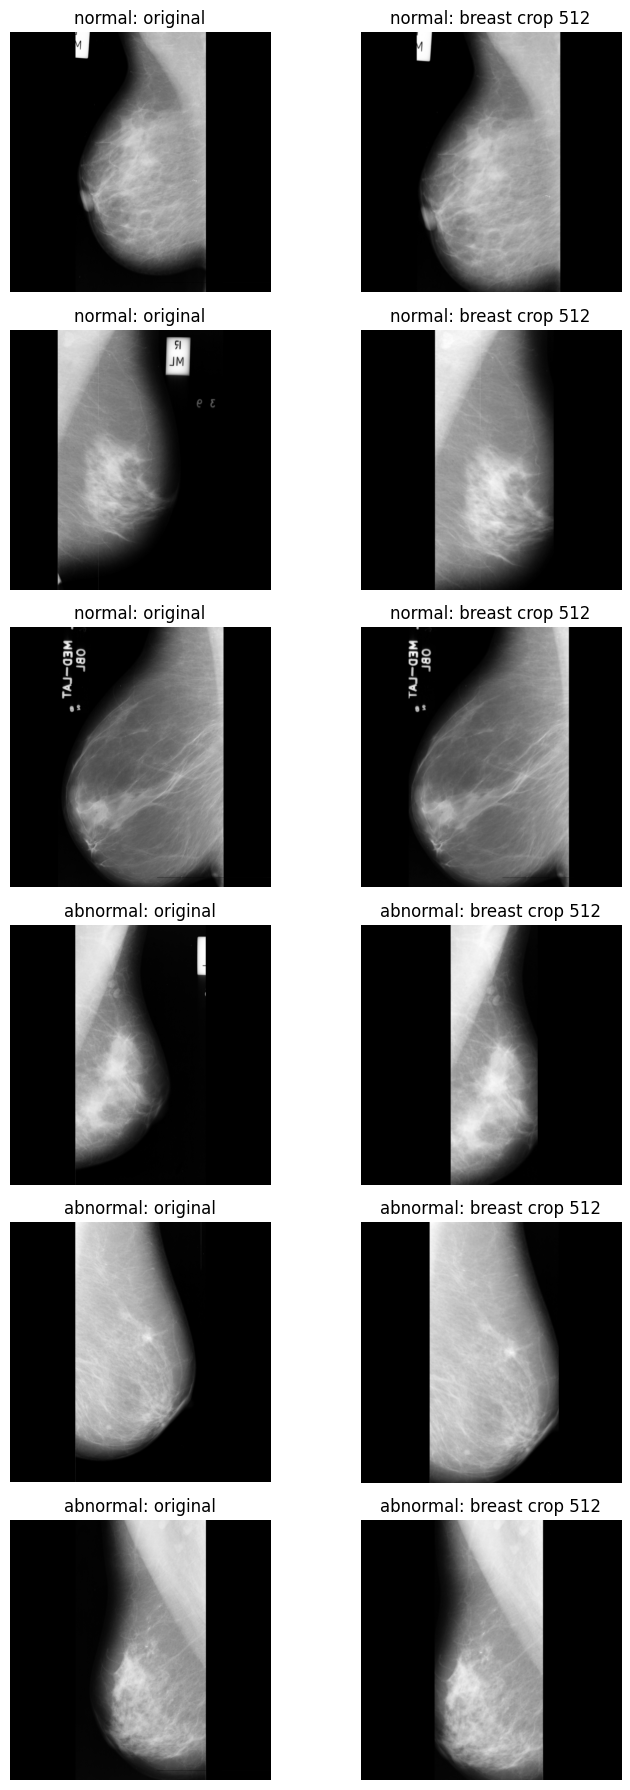

In [7]:
def otsu_threshold(gray):
    hist = np.bincount(
        gray.ravel(),
        minlength=256,
    ).astype(np.float64)

    prob = hist / max(gray.size, 1)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]

    sigma = (
        (mu_t * omega - mu) ** 2
        / np.maximum(
            omega * (1 - omega),
            1e-12,
        )
    )

    sigma[(omega <= 0) | (omega >= 1)] = 0

    return int(np.argmax(sigma))


def breast_bbox(gray_u8, pad_frac=0.02):
    h, w = gray_u8.shape

    mask = gray_u8 > max(
        otsu_threshold(gray_u8),
        5,
    )

    mask = ndimage.binary_opening(
        mask,
        structure=np.ones((3, 3)),
    )

    mask = ndimage.binary_closing(
        mask,
        structure=np.ones((7, 7)),
    )

    labels, n_labels = ndimage.label(mask)

    if n_labels == 0:
        return (0, 0, w, h)

    counts = np.bincount(labels.ravel())
    counts[0] = 0

    ys, xs = np.where(
        labels == counts.argmax()
    )

    if len(xs) == 0:
        return (0, 0, w, h)

    pad = int(
        round(pad_frac * max(h, w))
    )

    return (
        max(int(xs.min()) - pad, 0),
        max(int(ys.min()) - pad, 0),
        min(int(xs.max()) + 1 + pad, w),
        min(int(ys.max()) + 1 + pad, h),
    )


def load_gray(path):
    return np.array(
        Image.open(path).convert("L"),
        dtype=np.uint8,
    )


def crop_pad_resize_image(
    gray_u8,
    bbox,
    size=IMG_SIZE,
):
    left, top, right, bottom = bbox

    crop = Image.fromarray(gray_u8).crop(
        (left, top, right, bottom)
    )

    cw, ch = crop.size
    side = max(cw, ch)

    canvas = Image.new(
        "L",
        (side, side),
        0,
    )

    canvas.paste(
        crop,
        (
            (side - cw) // 2,
            (side - ch) // 2,
        ),
    )

    return np.array(
        canvas.resize(
            (size, size),
            RESAMPLE_BILINEAR,
        ),
        dtype=np.uint8,
    )


def preprocess_mammogram(path):
    original = load_gray(path)
    bbox = breast_bbox(original)

    return crop_pad_resize_image(
        original,
        bbox,
    )


def safe_sid(sample_id):
    return str(sample_id).replace(
        os.sep,
        "_",
    )


def cache_path(sample_id):
    return os.path.join(
        CACHE_DIR,
        "img",
        safe_sid(sample_id) + ".png",
    )


def meta_path(sample_id):
    return os.path.join(
        CACHE_DIR,
        "meta",
        safe_sid(sample_id) + ".json",
    )


def cache_signature(row):
    path = str(row.full_image_path)

    return {
        "preprocess_version": PREPROCESS_VERSION,
        "sample_id": str(row.sample_id),
        "full_image_path": path,
        "file_size": int(os.path.getsize(path)),
        "file_mtime": float(os.path.getmtime(path)),
        "img_size": int(IMG_SIZE),
    }


def cache_valid(row):
    if not (
        os.path.exists(cache_path(row.sample_id))
        and os.path.exists(meta_path(row.sample_id))
    ):
        return False

    try:
        with open(
            meta_path(row.sample_id),
            "r",
        ) as f:
            old = json.load(f)
    except Exception:
        return False

    return old == cache_signature(row)


def build_image_cache(dataframe, name):
    os.makedirs(
        os.path.join(CACHE_DIR, "img"),
        exist_ok=True,
    )

    os.makedirs(
        os.path.join(CACHE_DIR, "meta"),
        exist_ok=True,
    )

    rebuilt = 0

    for row in tqdm(
        dataframe.itertuples(),
        total=len(dataframe),
        desc=f"preprocess {name}",
    ):
        if cache_valid(row):
            continue

        processed = preprocess_mammogram(
            row.full_image_path
        )

        Image.fromarray(processed).save(
            cache_path(row.sample_id)
        )

        with open(
            meta_path(row.sample_id),
            "w",
        ) as f:
            json.dump(
                cache_signature(row),
                f,
                indent=2,
            )

        rebuilt += 1

    print(
        f"{name}: rebuilt "
        f"{rebuilt}/{len(dataframe)} cached images"
    )


def show_crop_examples(n_per_class=3):
    examples = []

    for label in [0, 1]:
        pool = train_df[
            train_df["label"] == label
        ]

        examples.append(
            pool.sample(
                min(n_per_class, len(pool)),
                random_state=SEED + label,
            )
        )

    ex = pd.concat(
        examples,
        ignore_index=True,
    )

    fig, axes = plt.subplots(
        len(ex),
        2,
        figsize=(8, 3.0 * len(ex)),
    )

    if len(ex) == 1:
        axes = np.array([axes])

    for i, row in ex.iterrows():
        original = load_gray(
            row.full_image_path
        )

        processed = preprocess_mammogram(
            row.full_image_path
        )

        class_name = (
            "normal"
            if row.label == 0
            else "abnormal"
        )

        axes[i, 0].imshow(
            original,
            cmap="gray",
        )

        axes[i, 0].set_title(
            f"{class_name}: original"
        )

        axes[i, 1].imshow(
            processed,
            cmap="gray",
        )

        axes[i, 1].set_title(
            f"{class_name}: breast crop 512"
        )

        for ax in axes[i]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


show_crop_examples()


## 6. Strict Feature Extraction with ImageNet-Pretrained ResNet-50

For the **primary normal-vs-abnormal anomaly experiment**, the feature extractor is not trained on the dissertation's benign-vs-malignant labels.

An ImageNet-pretrained ResNet-50 is frozen and its final classification head is removed, producing a 2048-dimensional image representation.

This makes the one-class claim stronger than reusing a feature extractor that was already supervised on benign vs malignant mammograms.


In [8]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


class FeatureDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(
            cache_path(row.sample_id)
        ).convert("L")

        arr = np.array(
            img,
            dtype=np.float32,
        ) / 255.0

        arr = np.stack(
            [arr, arr, arr],
            axis=0,
        )

        tensor = torch.from_numpy(arr)

        tensor = (
            tensor - IMAGENET_MEAN
        ) / IMAGENET_STD

        return {
            "image": tensor.float(),
            "label": int(row.label),
            "sample_id": str(row.sample_id),
            "patient_id": str(row.patient_id),
            "source": str(row.source),
        }


def build_imagenet_resnet50_encoder():
    try:
        weights = (
            models.ResNet50_Weights.IMAGENET1K_V2
        )

        model = models.resnet50(
            weights=weights
        )

    except Exception as exc:
        raise RuntimeError(
            "Could not load ImageNet-pretrained ResNet-50 weights. "
            "The primary experiment should not silently use random weights. "
            "Reconnect Colab to the internet or ensure torchvision weights "
            "are cached, then rerun this cell."
        ) from exc

    feature_dim = model.fc.in_features
    model.fc = nn.Identity()

    model.eval()

    for parameter in model.parameters():
        parameter.requires_grad = False

    return model.to(device), feature_dim


def extract_features_split(
    model,
    dataframe,
    name,
):
    loader = DataLoader(
        FeatureDataset(dataframe),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    feats = []
    labels = []
    sample_ids = []
    patient_ids = []
    sources = []

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc=f"features {name}",
        ):
            z = model(
                batch["image"].to(device)
            ).detach().cpu().numpy()

            feats.append(z)

            labels.extend([
                int(x)
                for x in batch["label"]
            ])

            sample_ids.extend([
                str(x)
                for x in batch["sample_id"]
            ])

            patient_ids.extend([
                str(x)
                for x in batch["patient_id"]
            ])

            sources.extend([
                str(x)
                for x in batch["source"]
            ])

    return {
        "X": np.vstack(feats).astype(np.float32),
        "y": np.array(labels, dtype=np.int64),
        "sample_id": np.array(sample_ids),
        "patient_id": np.array(patient_ids),
        "source": np.array(sources),
    }


def dataframe_fingerprint(dataframe):
    payload = (
        dataframe[
            [
                "sample_id",
                "patient_id",
                "label",
                "source",
                "full_image_path",
                "split",
            ]
        ]
        .sort_values("sample_id")
        .to_csv(index=False)
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()


DATASET_FINGERPRINT = dataframe_fingerprint(df)


def feature_cache_valid():
    if not os.path.exists(FEATURE_CACHE):
        return False

    try:
        data = np.load(
            FEATURE_CACHE,
            allow_pickle=False,
        )

        valid = (
            str(data["dataset_fingerprint"])
            == DATASET_FINGERPRINT
            and str(data["encoder_name"])
            == "imagenet_resnet50_v2"
            and list(data["train_sample_id"].astype(str))
            == list(train_df["sample_id"].astype(str))
            and list(data["val_sample_id"].astype(str))
            == list(val_df["sample_id"].astype(str))
            and list(data["test_sample_id"].astype(str))
            == list(test_df["sample_id"].astype(str))
        )

        data.close()
        return bool(valid)

    except Exception:
        return False


def save_feature_cache(
    train_feat,
    val_feat,
    test_feat,
):
    np.savez_compressed(
        FEATURE_CACHE,
        dataset_fingerprint=np.array(
            DATASET_FINGERPRINT
        ),
        encoder_name=np.array(
            "imagenet_resnet50_v2"
        ),
        train_X=train_feat["X"],
        train_y=train_feat["y"],
        train_sample_id=train_feat["sample_id"],
        train_patient_id=train_feat["patient_id"],
        train_source=train_feat["source"],
        val_X=val_feat["X"],
        val_y=val_feat["y"],
        val_sample_id=val_feat["sample_id"],
        val_patient_id=val_feat["patient_id"],
        val_source=val_feat["source"],
        test_X=test_feat["X"],
        test_y=test_feat["y"],
        test_sample_id=test_feat["sample_id"],
        test_patient_id=test_feat["patient_id"],
        test_source=test_feat["source"],
    )


if feature_cache_valid():
    print(
        "Loaded cached ImageNet ResNet-50 features:",
        FEATURE_CACHE,
    )

    data = np.load(
        FEATURE_CACHE,
        allow_pickle=False,
    )

    train_feat = {
        "X": data["train_X"],
        "y": data["train_y"],
        "sample_id": data["train_sample_id"].astype(str),
        "patient_id": data["train_patient_id"].astype(str),
        "source": data["train_source"].astype(str),
    }

    val_feat = {
        "X": data["val_X"],
        "y": data["val_y"],
        "sample_id": data["val_sample_id"].astype(str),
        "patient_id": data["val_patient_id"].astype(str),
        "source": data["val_source"].astype(str),
    }

    test_feat = {
        "X": data["test_X"],
        "y": data["test_y"],
        "sample_id": data["test_sample_id"].astype(str),
        "patient_id": data["test_patient_id"].astype(str),
        "source": data["test_source"].astype(str),
    }

    data.close()

else:
    build_image_cache(
        train_df,
        "train",
    )

    build_image_cache(
        val_df,
        "validation",
    )

    build_image_cache(
        test_df,
        "locked_test",
    )

    encoder, feature_dim = (
        build_imagenet_resnet50_encoder()
    )

    print(
        "Frozen feature dimension:",
        feature_dim,
    )

    train_feat = extract_features_split(
        encoder,
        train_df,
        "train",
    )

    val_feat = extract_features_split(
        encoder,
        val_df,
        "validation",
    )

    test_feat = extract_features_split(
        encoder,
        test_df,
        "locked_test",
    )

    save_feature_cache(
        train_feat,
        val_feat,
        test_feat,
    )

    del encoder

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        "Saved feature cache:",
        FEATURE_CACHE,
    )


for name, feat in [
    ("train", train_feat),
    ("validation", val_feat),
    ("locked_test", test_feat),
]:
    print(
        name,
        feat["X"].shape,
        "abnormal rate",
        round(float(feat["y"].mean()), 4),
    )


assert (
    list(train_feat["sample_id"].astype(str))
    == list(train_df["sample_id"].astype(str))
)

assert (
    list(val_feat["sample_id"].astype(str))
    == list(val_df["sample_id"].astype(str))
)

assert (
    list(test_feat["sample_id"].astype(str))
    == list(test_df["sample_id"].astype(str))
)

print(
    "Feature/label alignment confirmed."
)


Loaded cached ImageNet ResNet-50 features: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/10_Normal_vs_Abnormal_Anomaly_Detection/features_imagenet_resnet50_breastcrop512.npz
train (224, 2048) abnormal rate 0.3571
validation (48, 2048) abnormal rate 0.3333
locked_test (50, 2048) abnormal rate 0.38
Feature/label alignment confirmed.


## 7. Fit One-Class Models Using Normal Training Features Only

Three complementary detectors are compared:

- **Mahalanobis distance** with Ledoit-Wolf covariance shrinkage
- **Isolation Forest**
- **One-Class SVM**

The scaler, PCA and every one-class detector are fitted **only on normal training features**. Abnormal training images are never used to define the normal feature distribution.


In [9]:
X_train = train_feat["X"]
y_train = train_feat["y"]

X_val = val_feat["X"]
y_val = val_feat["y"]

X_test = test_feat["X"]
y_test = test_feat["y"]


normal_mask = y_train == 0

if normal_mask.sum() < 20:
    raise ValueError(
        "Too few normal training samples "
        "for one-class modelling."
    )

X_normal = X_train[normal_mask]

print(
    "Normal training samples used "
    f"for one-class fitting: "
    f"{len(X_normal)} / {len(X_train)}"
)


# ------------------------------------------------------------
# Standardisation and PCA: fitted only on normal train
# ------------------------------------------------------------

scaler = StandardScaler().fit(
    X_normal
)

Z_normal = scaler.transform(
    X_normal
)

nmax = min(
    MAX_PCA_COMPONENTS,
    Z_normal.shape[0] - 1,
    Z_normal.shape[1],
)

if nmax < 2:
    raise ValueError(
        "Too few normal training samples "
        "for PCA/covariance modelling."
    )

pca_probe = PCA(
    n_components=nmax,
    svd_solver="full",
).fit(Z_normal)

cum = np.cumsum(
    pca_probe.explained_variance_ratio_
)

if cum[-1] >= PCA_VARIANCE_TARGET:
    n_components = int(
        np.searchsorted(
            cum,
            PCA_VARIANCE_TARGET,
        ) + 1
    )
else:
    n_components = int(nmax)

pca = PCA(
    n_components=n_components,
    svd_solver="full",
).fit(Z_normal)

print(
    f"PCA components: {n_components} | "
    "variance retained: "
    f"{pca.explained_variance_ratio_.sum():.3f}"
)


def transform_features(X):
    return pca.transform(
        scaler.transform(X)
    )


Z_train = transform_features(
    X_train
)

Z_val = transform_features(
    X_val
)

Z_test = transform_features(
    X_test
)

Z_normal_pca = transform_features(
    X_normal
)


# ------------------------------------------------------------
# Detector 1: Mahalanobis distance
# ------------------------------------------------------------

mahal = LedoitWolf().fit(
    Z_normal_pca
)


def score_mahalanobis(Z):
    diff = Z - mahal.location_

    return np.einsum(
        "ij,jk,ik->i",
        diff,
        mahal.precision_,
        diff,
    )


# ------------------------------------------------------------
# Detector 2: Isolation Forest
# ------------------------------------------------------------

iforest = IsolationForest(
    n_estimators=500,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
).fit(Z_normal_pca)


def score_iforest(Z):
    # Higher = more anomalous
    return -iforest.score_samples(Z)


# ------------------------------------------------------------
# Detector 3: One-Class SVM
# ------------------------------------------------------------

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05,
).fit(Z_normal_pca)


def score_ocsvm(Z):
    # decision_function: higher = more normal
    # negate so higher = more anomalous
    return -ocsvm.decision_function(Z).ravel()


scores = {
    "Mahalanobis": {
        "val": score_mahalanobis(Z_val),
        "test": score_mahalanobis(Z_test),
    },
    "IsolationForest": {
        "val": score_iforest(Z_val),
        "test": score_iforest(Z_test),
    },
    "OneClassSVM": {
        "val": score_ocsvm(Z_val),
        "test": score_ocsvm(Z_test),
    },
}


for method, obj in scores.items():
    print(
        method,
        "validation score range:",
        (
            float(obj["val"].min()),
            float(obj["val"].max()),
        ),
    )


Normal training samples used for one-class fitting: 144 / 224
PCA components: 110 | variance retained: 0.951
Mahalanobis validation score range: (12.719544410705566, 142.1765899658203)
IsolationForest validation score range: (0.3372949133937497, 0.42016783680109787)
OneClassSVM validation score range: (-0.5278585419399482, 0.11494663937776162)


## 8. Validation-Only Threshold Selection

ROC-AUC and PR-AUC are threshold-free.

For threshold-dependent metrics, the operating threshold is selected **only on the validation set** using Youden's J statistic:

`sensitivity + specificity - 1`

The selected threshold is then frozen before the locked-test evaluation.


In [10]:
def metrics_from_scores(
    y_true,
    score,
    threshold,
):
    y_true = np.asarray(
        y_true
    ).astype(int)

    score = np.asarray(
        score,
        dtype=float,
    )

    y_pred = (
        score >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    return {
        "roc_auc": roc_auc_score(
            y_true,
            score,
        ),
        "pr_auc": average_precision_score(
            y_true,
            score,
        ),
        "threshold": float(threshold),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "sensitivity": (
            tp / (tp + fn)
            if (tp + fn)
            else np.nan
        ),
        "specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold_youden(
    y_true,
    score,
):
    y_true = np.asarray(
        y_true
    ).astype(int)

    score = np.asarray(
        score,
        dtype=float,
    )

    candidates = np.unique(
        np.quantile(
            score,
            np.linspace(
                0.01,
                0.99,
                199,
            ),
        )
    )

    best = None

    for threshold in candidates:
        metrics = metrics_from_scores(
            y_true,
            score,
            threshold,
        )

        youden_j = (
            metrics["sensitivity"]
            + metrics["specificity"]
            - 1
        )

        tie_break = (
            youden_j,
            metrics["balanced_accuracy"],
            metrics["sensitivity"],
            -threshold,
        )

        if (
            best is None
            or tie_break > best[0]
        ):
            best = (
                tie_break,
                threshold,
            )

    return float(best[1])


validation_rows = []
thresholds = {}

for method, obj in scores.items():
    threshold = select_threshold_youden(
        y_val,
        obj["val"],
    )

    thresholds[method] = threshold

    validation_rows.append({
        "method": method,
        **metrics_from_scores(
            y_val,
            obj["val"],
            threshold,
        ),
    })


validation_metrics = pd.DataFrame(
    validation_rows
)

display(
    validation_metrics.round(4)
)


validation_predictions = pd.concat([
    pd.DataFrame({
        "method": method,
        "sample_id": val_feat["sample_id"],
        "patient_id": val_feat["patient_id"],
        "source": val_feat["source"],
        "y_true": y_val,
        "anomaly_score": obj["val"],
        "threshold": thresholds[method],
        "y_pred": (
            obj["val"]
            >= thresholds[method]
        ).astype(int),
    })
    for method, obj in scores.items()
], ignore_index=True)


validation_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_metrics.csv",
    ),
    index=False,
)

validation_predictions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_predictions.csv",
    ),
    index=False,
)

with open(
    os.path.join(
        OUTPUT_DIR,
        "validation_selected_thresholds.json",
    ),
    "w",
) as f:
    json.dump(
        thresholds,
        f,
        indent=2,
    )

print(
    "Validation thresholds:",
    thresholds,
)


,method,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,Mahalanobis,0.6406,0.4760,37.7835,0.7083,0.6875,0.5882,0.5556,0.6250,0.7500,24,8,6,10
1,IsolationForest,0.6660,0.4515,0.3590,0.6875,0.7031,0.6154,0.5217,0.7500,0.6562,21,11,4,12
2,OneClassSVM,0.5566,0.4265,-0.4243,0.5833,0.6406,0.5652,0.4333,0.8125,0.4688,15,17,3,13


Validation thresholds: {'Mahalanobis': 37.7835205078125, 'IsolationForest': 0.3589614206498895, 'OneClassSVM': -0.4243070361043943}


## 9. Locked Test Evaluation

The locked test set is now evaluated once using the validation-selected thresholds.

**Do not change thresholds after seeing the test results.**


In [11]:
test_rows = []
test_prediction_parts = []

for method, obj in scores.items():
    threshold = thresholds[method]

    metrics = metrics_from_scores(
        y_test,
        obj["test"],
        threshold,
    )

    test_rows.append({
        "method": method,
        **metrics,
    })

    test_prediction_parts.append(
        pd.DataFrame({
            "method": method,
            "sample_id": test_feat["sample_id"],
            "patient_id": test_feat["patient_id"],
            "source": test_feat["source"],
            "y_true": y_test,
            "anomaly_score": obj["test"],
            "threshold": threshold,
            "y_pred": (
                obj["test"] >= threshold
            ).astype(int),
        })
    )


test_metrics = pd.DataFrame(
    test_rows
)

test_predictions = pd.concat(
    test_prediction_parts,
    ignore_index=True,
)

display(
    test_metrics.round(4)
)


test_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "locked_test_metrics.csv",
    ),
    index=False,
)

test_predictions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "locked_test_predictions.csv",
    ),
    index=False,
)


,method,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,Mahalanobis,0.5705,0.5214,37.7835,0.54,0.5068,0.3784,0.3889,0.3684,0.6452,20,11,12,7
1,IsolationForest,0.5688,0.4970,0.3590,0.56,0.5331,0.4211,0.4211,0.4211,0.6452,20,11,11,8
2,OneClassSVM,0.5008,0.4358,-0.4243,0.52,0.5722,0.5556,0.4286,0.7895,0.3548,11,20,4,15


## 10. Patient-Level Bootstrap Confidence Intervals

Confidence intervals are bootstrapped by patient rather than image because a patient may contribute multiple views.


In [12]:
def bootstrap_ci_for_method(
    pred,
    n_boot=BOOTSTRAP_N,
    seed=SEED,
):
    rng = np.random.default_rng(
        seed
    )

    by_patient = {
        patient_id: group
        for patient_id, group
        in pred.groupby("patient_id")
    }

    patient_ids = np.array(
        list(by_patient)
    )

    rows = []

    for _ in range(n_boot):
        sampled = rng.choice(
            patient_ids,
            size=len(patient_ids),
            replace=True,
        )

        bootstrap_sample = pd.concat(
            [
                by_patient[patient_id]
                for patient_id in sampled
            ],
            ignore_index=True,
        )

        if (
            bootstrap_sample["y_true"]
            .nunique()
            < 2
        ):
            continue

        metrics = metrics_from_scores(
            bootstrap_sample["y_true"],
            bootstrap_sample["anomaly_score"],
            float(
                bootstrap_sample[
                    "threshold"
                ].iloc[0]
            ),
        )

        rows.append({
            key: metrics[key]
            for key in [
                "roc_auc",
                "pr_auc",
                "sensitivity",
                "specificity",
                "balanced_accuracy",
                "f1",
            ]
        })

    return pd.DataFrame(rows)


ci_rows = []

for method in scores:
    pred = test_predictions[
        test_predictions["method"] == method
    ].copy()

    observed = metrics_from_scores(
        pred["y_true"],
        pred["anomaly_score"],
        float(pred["threshold"].iloc[0]),
    )

    boot = bootstrap_ci_for_method(
        pred
    )

    for metric in [
        "roc_auc",
        "pr_auc",
        "sensitivity",
        "specificity",
        "balanced_accuracy",
        "f1",
    ]:
        ci_rows.append({
            "method": method,
            "metric": metric,
            "observed": observed[metric],
            "ci_low": boot[metric].quantile(0.025),
            "ci_high": boot[metric].quantile(0.975),
            "n_boot": len(boot),
        })


ci_df = pd.DataFrame(
    ci_rows
)

display(
    ci_df.round(4)
)

ci_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "locked_test_patient_bootstrap_ci.csv",
    ),
    index=False,
)


,method,metric,observed,ci_low,ci_high,n_boot
0,Mahalanobis,roc_auc,0.5705,0.3989,0.7465,1000
1,Mahalanobis,pr_auc,0.5214,0.3348,0.7325,1000
2,Mahalanobis,sensitivity,0.3684,0.1333,0.6000,1000
3,Mahalanobis,specificity,0.6452,0.4828,0.8000,1000
4,Mahalanobis,balanced_accuracy,0.5068,0.3604,0.6500,1000
5,Mahalanobis,f1,0.3784,0.1429,0.5791,1000
6,IsolationForest,roc_auc,0.5688,0.4021,0.7429,1000
7,IsolationForest,pr_auc,0.4970,0.3240,0.7233,1000
8,IsolationForest,sensitivity,0.4211,0.1737,0.6667,1000
9,IsolationForest,specificity,0.6452,0.4828,0.8000,1000


## 11. Paired AUC Comparison Between One-Class Methods

The paired bootstrap compares detector AUCs on the **same locked-test patients**.

A confidence interval containing zero means the experiment does not provide clear evidence that one detector has a higher AUC than the other.


In [13]:
from itertools import combinations


def paired_auc_delta(
    method_a,
    method_b,
    n_boot=BOOTSTRAP_N,
    seed=SEED,
):
    a = (
        test_predictions[
            test_predictions["method"]
            == method_a
        ][
            [
                "sample_id",
                "patient_id",
                "y_true",
                "anomaly_score",
            ]
        ]
        .rename(
            columns={
                "anomaly_score": "score_a"
            }
        )
    )

    b = (
        test_predictions[
            test_predictions["method"]
            == method_b
        ][
            [
                "sample_id",
                "anomaly_score",
            ]
        ]
        .rename(
            columns={
                "anomaly_score": "score_b"
            }
        )
    )

    merged = a.merge(
        b,
        on="sample_id",
    )

    assert (
        len(merged)
        == len(a)
        == len(b)
    )

    observed = (
        roc_auc_score(
            merged["y_true"],
            merged["score_a"],
        )
        - roc_auc_score(
            merged["y_true"],
            merged["score_b"],
        )
    )

    rng = np.random.default_rng(
        seed
    )

    by_patient = {
        patient_id: group
        for patient_id, group
        in merged.groupby("patient_id")
    }

    patient_ids = np.array(
        list(by_patient)
    )

    differences = []

    for _ in range(n_boot):
        sampled = rng.choice(
            patient_ids,
            size=len(patient_ids),
            replace=True,
        )

        bootstrap_sample = pd.concat(
            [
                by_patient[patient_id]
                for patient_id in sampled
            ],
            ignore_index=True,
        )

        if (
            bootstrap_sample["y_true"]
            .nunique()
            < 2
        ):
            continue

        differences.append(
            roc_auc_score(
                bootstrap_sample["y_true"],
                bootstrap_sample["score_a"],
            )
            - roc_auc_score(
                bootstrap_sample["y_true"],
                bootstrap_sample["score_b"],
            )
        )

    differences = np.asarray(
        differences
    )

    return {
        "comparison": (
            f"{method_a} - {method_b}"
        ),
        "delta_auc": observed,
        "ci_low": np.quantile(
            differences,
            0.025,
        ),
        "ci_high": np.quantile(
            differences,
            0.975,
        ),
        "n_boot": len(differences),
    }


paired_rows = []

for method_a, method_b in combinations(
    scores.keys(),
    2,
):
    paired_rows.append(
        paired_auc_delta(
            method_a,
            method_b,
        )
    )


paired_df = pd.DataFrame(
    paired_rows
)

display(
    paired_df.round(4)
)

paired_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "paired_method_auc_comparisons.csv",
    ),
    index=False,
)


,comparison,delta_auc,ci_low,ci_high,n_boot
0,Mahalanobis - IsolationForest,0.0017,-0.0463,0.0521,1000
1,Mahalanobis - OneClassSVM,0.0696,-0.0718,0.2133,1000
2,IsolationForest - OneClassSVM,0.0679,-0.0802,0.2222,1000


## 12. Source-Stratified Sanity Check

When multiple data sources are present, this table reports test performance separately by source **only when that source contains both classes**.

This is a diagnostic against hidden dataset effects; it is not a substitute for the source-confounding guard earlier in the notebook.


In [14]:
source_rows = []

for method in scores:
    method_pred = test_predictions[
        test_predictions["method"] == method
    ]

    for source_name, group in method_pred.groupby(
        "source"
    ):
        if group["y_true"].nunique() < 2:
            continue

        metrics = metrics_from_scores(
            group["y_true"],
            group["anomaly_score"],
            float(
                group["threshold"].iloc[0]
            ),
        )

        source_rows.append({
            "method": method,
            "source": source_name,
            "images": len(group),
            "patients": group["patient_id"].nunique(),
            **metrics,
        })


source_metrics = pd.DataFrame(
    source_rows
)

if len(source_metrics):
    display(
        source_metrics.round(4)
    )

    source_metrics.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "locked_test_source_stratified_metrics.csv",
        ),
        index=False,
    )

else:
    print(
        "No source-stratified ROC-AUC table produced. "
        "This is expected for a single-source dataset."
    )


,method,source,images,patients,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,Mahalanobis,mini-MIAS,50,25,0.5705,0.5214,37.7835,0.54,0.5068,0.3784,0.3889,0.3684,0.6452,20,11,12,7
1,IsolationForest,mini-MIAS,50,25,0.5688,0.4970,0.3590,0.56,0.5331,0.4211,0.4211,0.4211,0.6452,20,11,11,8
2,OneClassSVM,mini-MIAS,50,25,0.5008,0.4358,-0.4243,0.52,0.5722,0.5556,0.4286,0.7895,0.3548,11,20,4,15


## 13. Dissertation Figures

For each one-class method, the notebook saves:

- normal vs abnormal anomaly-score distributions,
- ROC and PR curves,
- confusion matrix using the frozen validation-selected threshold.


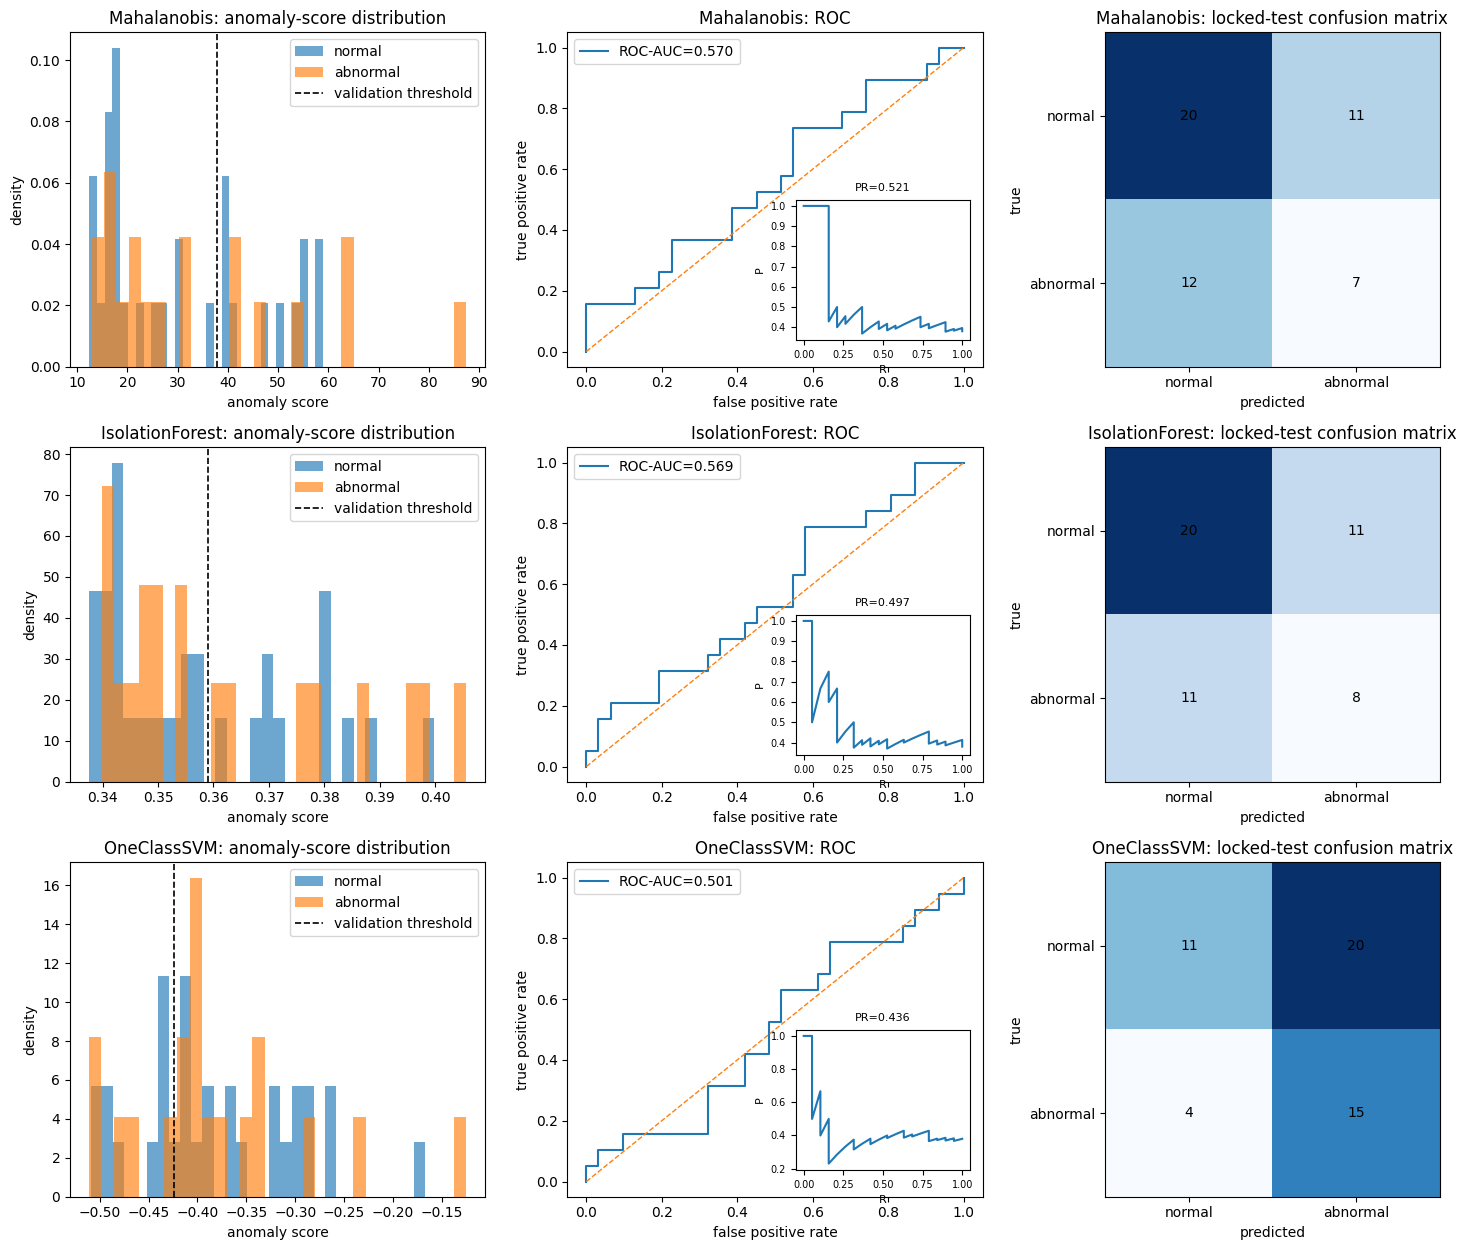

Saved result figure: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/10_Normal_vs_Abnormal_Anomaly_Detection/normal_vs_abnormal_test_figures.png
Saved dissertation figure copy: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Figures/Anomaly/10_normal_vs_abnormal_test_figures.png


In [15]:
fig, axes = plt.subplots(
    len(scores),
    3,
    figsize=(
        15,
        4.2 * len(scores),
    ),
)

if len(scores) == 1:
    axes = np.array([axes])


for row_idx, method in enumerate(
    scores.keys()
):
    pred = test_predictions[
        test_predictions["method"] == method
    ].copy()

    threshold = float(
        pred["threshold"].iloc[0]
    )

    # --------------------------------------------------------
    # Anomaly-score distributions
    # --------------------------------------------------------

    ax = axes[row_idx, 0]

    ax.hist(
        pred.loc[
            pred["y_true"] == 0,
            "anomaly_score",
        ],
        bins=30,
        alpha=0.65,
        label="normal",
        density=True,
    )

    ax.hist(
        pred.loc[
            pred["y_true"] == 1,
            "anomaly_score",
        ],
        bins=30,
        alpha=0.65,
        label="abnormal",
        density=True,
    )

    ax.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="validation threshold",
    )

    ax.set_title(
        f"{method}: anomaly-score distribution"
    )

    ax.set_xlabel(
        "anomaly score"
    )

    ax.set_ylabel(
        "density"
    )

    ax.legend()


    # --------------------------------------------------------
    # ROC + inset PR
    # --------------------------------------------------------

    ax = axes[row_idx, 1]

    fpr, tpr, _ = roc_curve(
        pred["y_true"],
        pred["anomaly_score"],
    )

    precision, recall, _ = (
        precision_recall_curve(
            pred["y_true"],
            pred["anomaly_score"],
        )
    )

    auc = roc_auc_score(
        pred["y_true"],
        pred["anomaly_score"],
    )

    pr_auc = average_precision_score(
        pred["y_true"],
        pred["anomaly_score"],
    )

    ax.plot(
        fpr,
        tpr,
        label=f"ROC-AUC={auc:.3f}",
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(
        f"{method}: ROC"
    )

    ax.set_xlabel(
        "false positive rate"
    )

    ax.set_ylabel(
        "true positive rate"
    )

    ax.legend()

    ax2 = ax.inset_axes(
        [0.55, 0.08, 0.42, 0.42]
    )

    ax2.plot(
        recall,
        precision,
    )

    ax2.set_title(
        f"PR={pr_auc:.3f}",
        fontsize=8,
    )

    ax2.set_xlabel(
        "R",
        fontsize=8,
    )

    ax2.set_ylabel(
        "P",
        fontsize=8,
    )

    ax2.tick_params(
        labelsize=7
    )


    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    ax = axes[row_idx, 2]

    cm = confusion_matrix(
        pred["y_true"],
        pred["y_pred"],
        labels=[0, 1],
    )

    ax.imshow(
        cm,
        cmap="Blues",
    )

    ax.set_xticks(
        [0, 1],
        ["normal", "abnormal"],
    )

    ax.set_yticks(
        [0, 1],
        ["normal", "abnormal"],
    )

    ax.set_xlabel(
        "predicted"
    )

    ax.set_ylabel(
        "true"
    )

    ax.set_title(
        f"{method}: locked-test confusion matrix"
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
            )


plt.tight_layout()

result_figure_path = os.path.join(
    OUTPUT_DIR,
    "normal_vs_abnormal_test_figures.png",
)

report_figure_path = os.path.join(
    FIGURE_DIR,
    "10_normal_vs_abnormal_test_figures.png",
)

plt.savefig(
    result_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.savefig(
    report_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved result figure:",
    result_figure_path,
)

print(
    "Saved dissertation figure copy:",
    report_figure_path,
)


## 14. Final Result Summary and Dissertation Framing

After the notebook has run, use the locked-test table and patient-level bootstrap confidence intervals.

Suggested framing:

> A separate normal-vs-abnormal one-class anomaly-detection experiment was conducted using mini-MIAS. The normal distribution was estimated using only normal training mammograms. Left/right mammograms from the same patient were grouped before train/validation/test splitting. ImageNet-pretrained ResNet-50 features were extracted after consistent breast-crop preprocessing, and Mahalanobis distance, Isolation Forest and One-Class SVM were evaluated. Operating thresholds were selected on a patient-disjoint validation set and frozen before locked-test evaluation.

### Interpretation rules

- Report this as **normal vs abnormal detection**, not benign vs malignant classification.
- Do not directly compare its AUC as if it were the same task as Notebook 09.
- A higher AUC here does **not** mean Notebook 09 was inferior; the tasks have different definitions and difficulty.
- mini-MIAS is small and relatively old, so confidence intervals and dataset limitations should be discussed.


### Model-selection wording

The **primary detector is selected using validation ROC-AUC** before locked-test interpretation.
The method with the highest observed locked-test ROC-AUC may be reported descriptively, but it must not be described as test-set model selection.


In [16]:
# Primary detector selection uses VALIDATION ROC-AUC only.
primary_validation_row = (
    validation_metrics
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .iloc[0]
)

primary_method = str(
    primary_validation_row["method"]
)

primary_test_row = test_metrics[
    test_metrics["method"] == primary_method
].iloc[0]

primary_test_auc = float(
    primary_test_row["roc_auc"]
)

primary_ci = ci_df[
    (ci_df["method"] == primary_method)
    & (ci_df["metric"] == "roc_auc")
].iloc[0]

# Highest locked-test AUC is descriptive only; it is NOT model selection.
highest_observed_test_row = (
    test_metrics
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .iloc[0]
)

highest_observed_test_method = str(
    highest_observed_test_row["method"]
)

highest_observed_test_auc = float(
    highest_observed_test_row["roc_auc"]
)


summary_text = f"""
Experiment: True normal-vs-abnormal mammogram anomaly detection

Primary encoder:
ImageNet-pretrained ResNet-50, frozen, 2048-dimensional features.

One-class fitting:
Only genuine normal training mammograms were used to fit the normal distribution.

Methods:
{", ".join(scores.keys())}

Primary method selected by validation ROC-AUC:
{primary_method}

Primary method locked-test ROC-AUC:
{primary_test_auc:.4f}

Primary method patient-level bootstrap 95% CI:
[{float(primary_ci["ci_low"]):.4f}, {float(primary_ci["ci_high"]):.4f}]

Highest observed locked-test ROC-AUC (descriptive only):
{highest_observed_test_method}: {highest_observed_test_auc:.4f}

Threshold:
Selected on validation data using Youden's J and frozen before test evaluation.

Important interpretation:
This is a normal-vs-abnormal detection experiment and should not be treated as
the same task as benign-vs-malignant classification or Notebook 09's benign
one-class malignant-case separability experiment.
""".strip()


print(summary_text)


with open(
    os.path.join(
        OUTPUT_DIR,
        "dissertation_summary.txt",
    ),
    "w",
    encoding="utf-8",
) as f:
    f.write(
        summary_text
    )


config = {
    "created_at": datetime.now().isoformat(),
    "experiment": "true_normal_vs_abnormal_anomaly_detection_miniMIAS",
    "framing": "mini-MIAS one-class modelling of genuinely normal mammograms; abnormal mammograms scored as deviations",
    "project_dir": PROJECT_DIR,
    "manifest_path": MANIFEST_PATH,
    "dataset_fingerprint": DATASET_FINGERPRINT,
    "encoder": "ImageNet ResNet-50 V2 weights, frozen feature extractor",
    "image_size": IMG_SIZE,
    "feature_dim": int(
        train_feat["X"].shape[1]
    ),
    "normal_train_images": int(
        (y_train == 0).sum()
    ),
    "pca_components": int(
        n_components
    ),
    "pca_variance_retained": float(
        pca.explained_variance_ratio_.sum()
    ),
    "methods": list(
        scores.keys()
    ),
    "threshold_rule": "validation Youden J",
    "bootstrap_n": BOOTSTRAP_N,
    "seed": SEED,
    "source_confounding_override": bool(
        ALLOW_SOURCE_CONFOUNDED_EXPLORATORY
    ),
    "primary_method_selection_rule": "highest validation ROC-AUC",
    "primary_method": primary_method,
    "primary_method_locked_test_auc": primary_test_auc,
    "highest_observed_locked_test_method_descriptive_only": highest_observed_test_method,
    "highest_observed_locked_test_auc_descriptive_only": highest_observed_test_auc,
}


with open(
    os.path.join(
        OUTPUT_DIR,
        "config.json",
    ),
    "w",
) as f:
    json.dump(
        config,
        f,
        indent=2,
    )


print(
    "\nSaved all Notebook 10 outputs to:",
    OUTPUT_DIR,
)


Experiment: True normal-vs-abnormal mammogram anomaly detection

Primary encoder:
ImageNet-pretrained ResNet-50, frozen, 2048-dimensional features.

One-class fitting:
Only genuine normal training mammograms were used to fit the normal distribution.

Methods:
Mahalanobis, IsolationForest, OneClassSVM

Primary method selected by validation ROC-AUC:
IsolationForest

Primary method locked-test ROC-AUC:
0.5688

Primary method patient-level bootstrap 95% CI:
[0.4021, 0.7429]

Highest observed locked-test ROC-AUC (descriptive only):
Mahalanobis: 0.5705

Threshold:
Selected on validation data using Youden's J and frozen before test evaluation.

Important interpretation:
This is a normal-vs-abnormal detection experiment and should not be treated as
the same task as benign-vs-malignant classification or Notebook 09's benign
one-class malignant-case separability experiment.

Saved all Notebook 10 outputs to: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/10